# Community detection in complex networks

Basics:
* Communities are **locally dense connected subgraphs** in a network.
* Community detection aims to uncover the inherent community structure of a network.

Definitions:
* Clique - a fully connected subgraph within a larger graph.
* Strong community - each node has more edges connecting it to other nodes inside the group than to nodes outside the group.
* Weak community - the total internal degree of the group exceeds its total external degree.

Approaches and algorithms:
* Graph partitioning
* Hierarchical clustering (Girvan–Newman)
* Modularity optimization (Louvain)

## Introduction to community detection

Lets start with a simple example of a small graph.

In [2]:
import networkx as nx

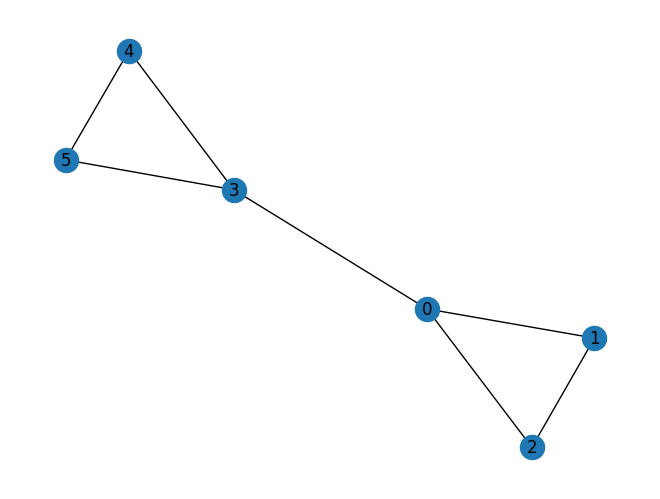

In [3]:
G = nx.Graph()
nx.add_cycle(G, [0, 1, 2])
nx.add_cycle(G, [3, 4, 5])
G.add_edge(0, 3)

nx.draw(G, with_labels=True)

How can we devide this graph into communities to get partitions of good quality? At first we'll do it by hand and validate if the partition is valid.

In [4]:
partition = [
    {0, 1, 2},
    {3, 4, 5},
]

nx.community.is_partition(G, partition)

True

Now, create a mapping between nodes and partitions, that will be of use for visualization and assesment of partition quality.

In [5]:
def create_node_to_partition_mapping(partition):
  node_to_partition = {}
  for idx, cluster_nodes in enumerate(partition):
      for node in cluster_nodes:
          node_to_partition[node] = idx
  return node_to_partition

node_to_partition = create_node_to_partition_mapping(partition)
node_to_partition

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}

Then visualize this simple graph again with color of nodes corresponding to the partition they belong to.

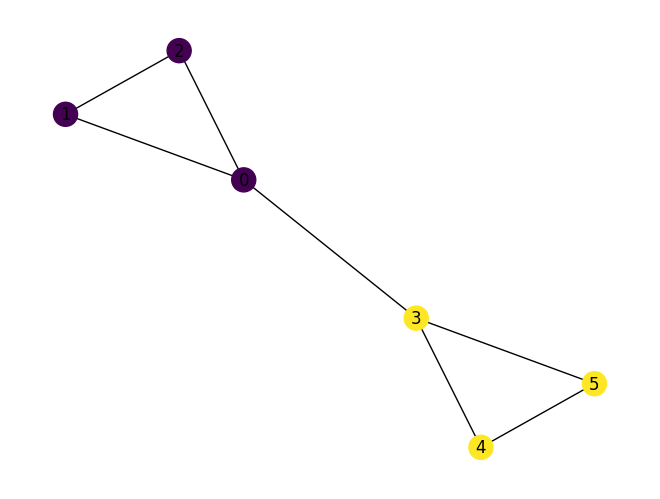

In [6]:
colors = [node_to_partition[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

## Modularity

Now with the defined partition, we need to look for an answer to the question of can we evaluate the goodness of this network partition, and in a broader context, any partition of any graph?

One possible answer is to compare the connection density of the groups to a random baseline, as random networks do not have groups.

The modularity measure is defined as the difference between the number of internal links in the clusters and the expected number of links in a random network.

$$Q = \frac{1}{L}\sum_C(L_C - \frac{k_C^2}{4L})$$

where:
- $L$ - total number of links
- $L_c$ - number of links inside cluster $C$
- $\frac{k_C^2}{4L}$ - number of links in a random network

NetworkX comes with an efficient implementation of modularity calculation ```nx.community.quality.modularity(G, partition)```, that we will use to measure partition quality.

In [7]:
nx.community.quality.modularity(G, partition)

0.35714285714285715

We can verify how the modularity value change if we decide to change the partition.

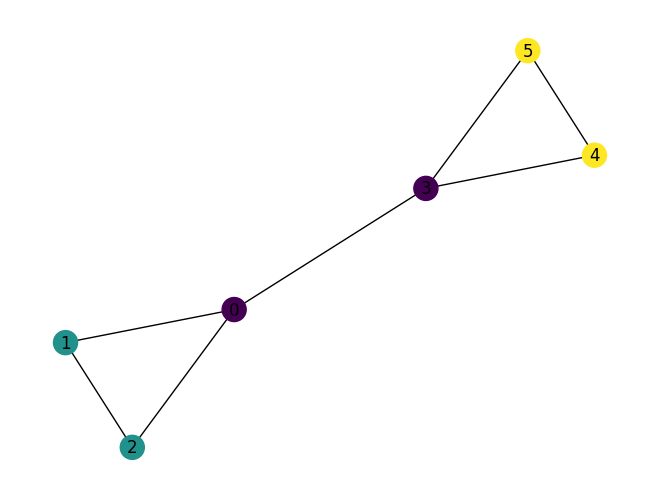

In [8]:
partition2 = [
    {0, 3},
    {1, 2},
    {4, 5},
]

colors = [create_node_to_partition_mapping(partition2)[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

In [9]:
nx.community.quality.modularity(G, partition2)

0.0816326530612245

## Setting up networks for study

In the next sections of this notebook, we will be working with different networks, both artificial and real-world and algorithms that will help us identify communities within those networks.

In [10]:
connected_caveman_graph = nx.connected_caveman_graph(4, 8)
small_world_network = nx.watts_strogatz_graph(34, 4, 0.15)
windmill_graph = nx.windmill_graph(5, 7)
gaussian_random_partition_graph = nx.gaussian_random_partition_graph(n=34, s=9, v=9, p_in=0.7, p_out=0.03, seed=42)
random_partition_graph = nx.random_partition_graph([10, 8, 5, 5, 3, 3], 0.8, 0.04, seed=42)
karate_club_network = nx.karate_club_graph()

### Task 1
The first task is to take a look at the networks that are going to be the subject of study. Prepare a visualization of the graphs defined in the previous cell. Place all of them on a single plot, remember to include subplot titles to be able to identify them and find the best positionig that helps to reveale the network structure.

#### Code

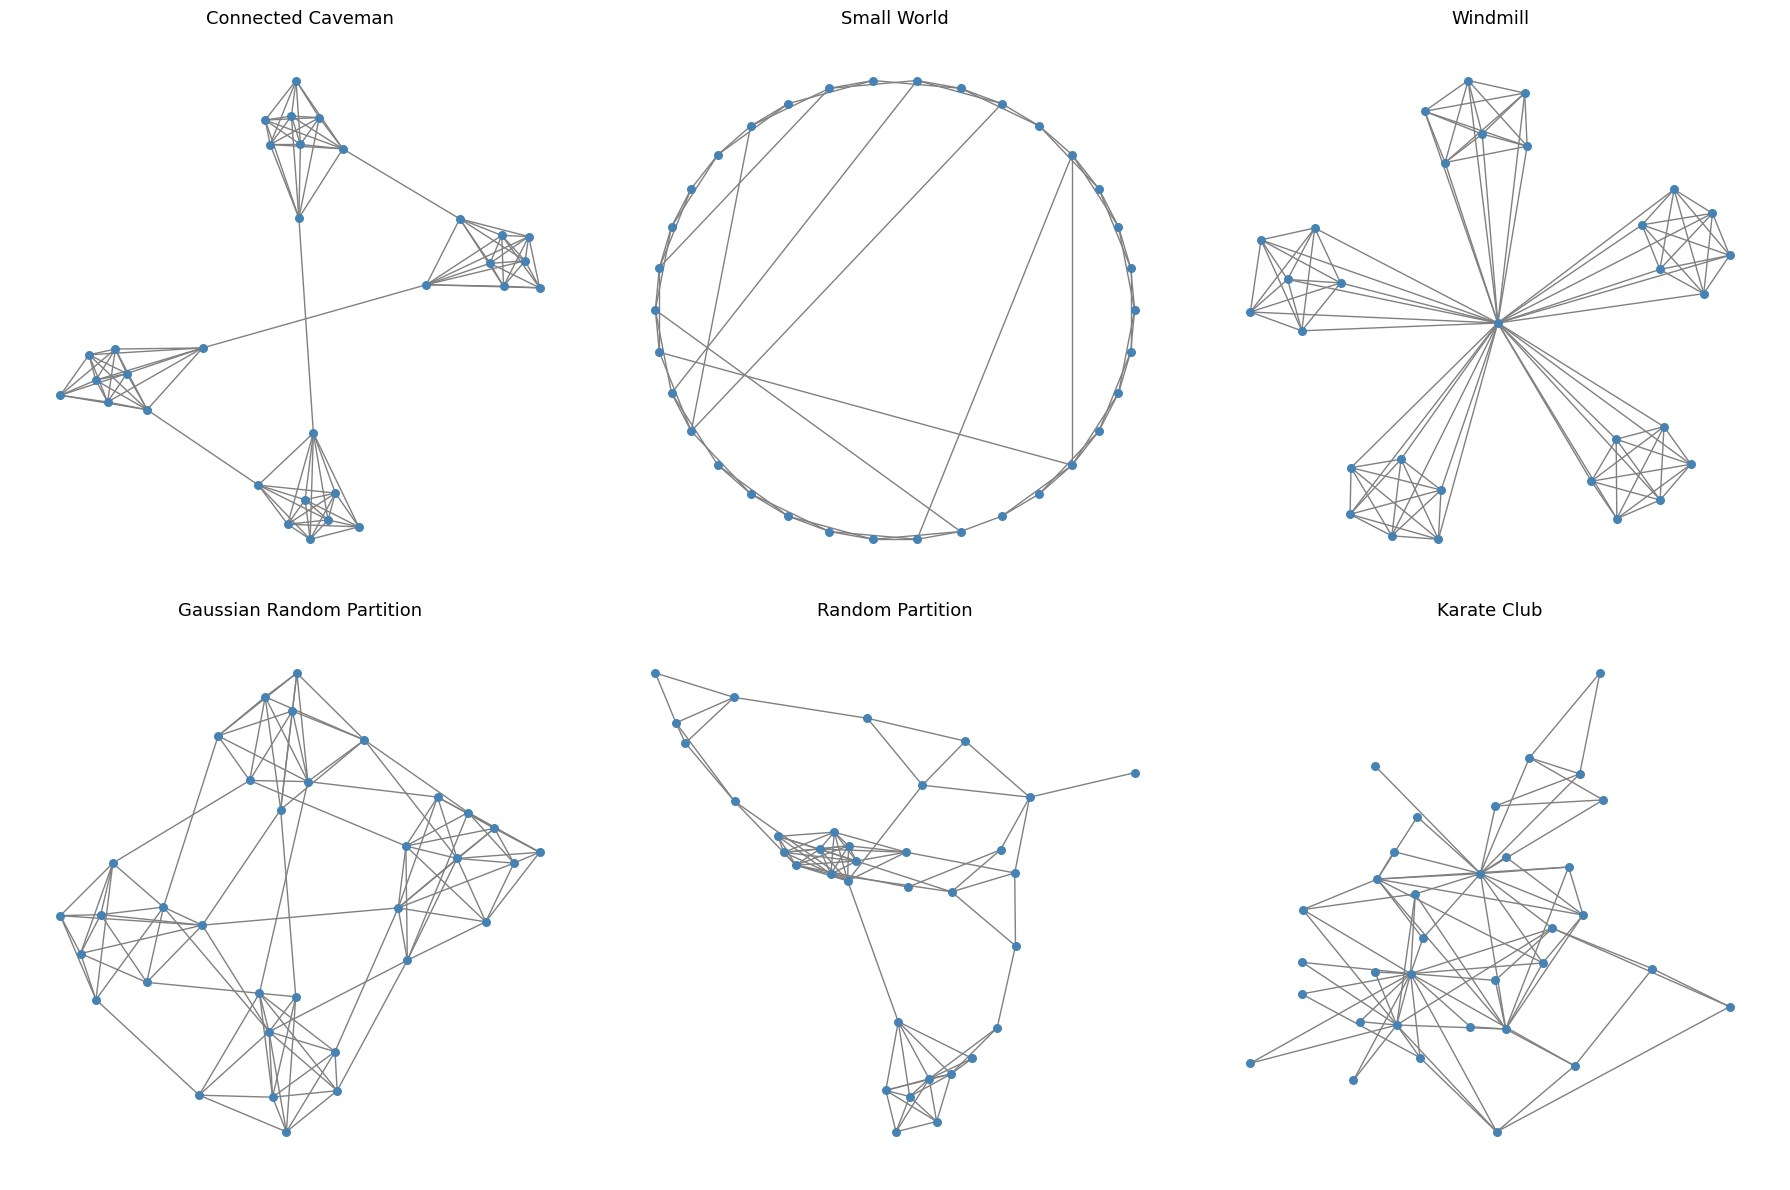

In [11]:
import matplotlib.pyplot as plt

networks = {
    "Connected Caveman": connected_caveman_graph,
    "Small World": small_world_network,
    "Windmill": windmill_graph,
    "Gaussian Random Partition": gaussian_random_partition_graph,
    "Random Partition": random_partition_graph,
    "Karate Club": karate_club_network,
}

layouts = {
    "Connected Caveman": nx.spring_layout,
    "Small World": nx.circular_layout,
    "Windmill": nx.spring_layout,
    "Gaussian Random Partition": nx.spring_layout,
    "Random Partition": nx.spring_layout,
    "Karate Club": nx.kamada_kawai_layout,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, G) in enumerate(networks.items()):
    pos = layouts[name](G, seed=42) if layouts[name] == nx.spring_layout else layouts[name](G)
    nx.draw(G, pos=pos, ax=axes[i], with_labels=False, node_size=30, node_color="steelblue", edge_color="gray")
    axes[i].set_title(name, fontsize=13)

plt.tight_layout()
plt.show()

## Cliques identification

### Task 2
Calculate the number of different size cliques present in each network and visualize them on a barplot.

Analyse and interpret the obtained results, write your conclusions in the cell below. What does the number of cliques says about those networks? Are they differnt or quite similar?

#### Code

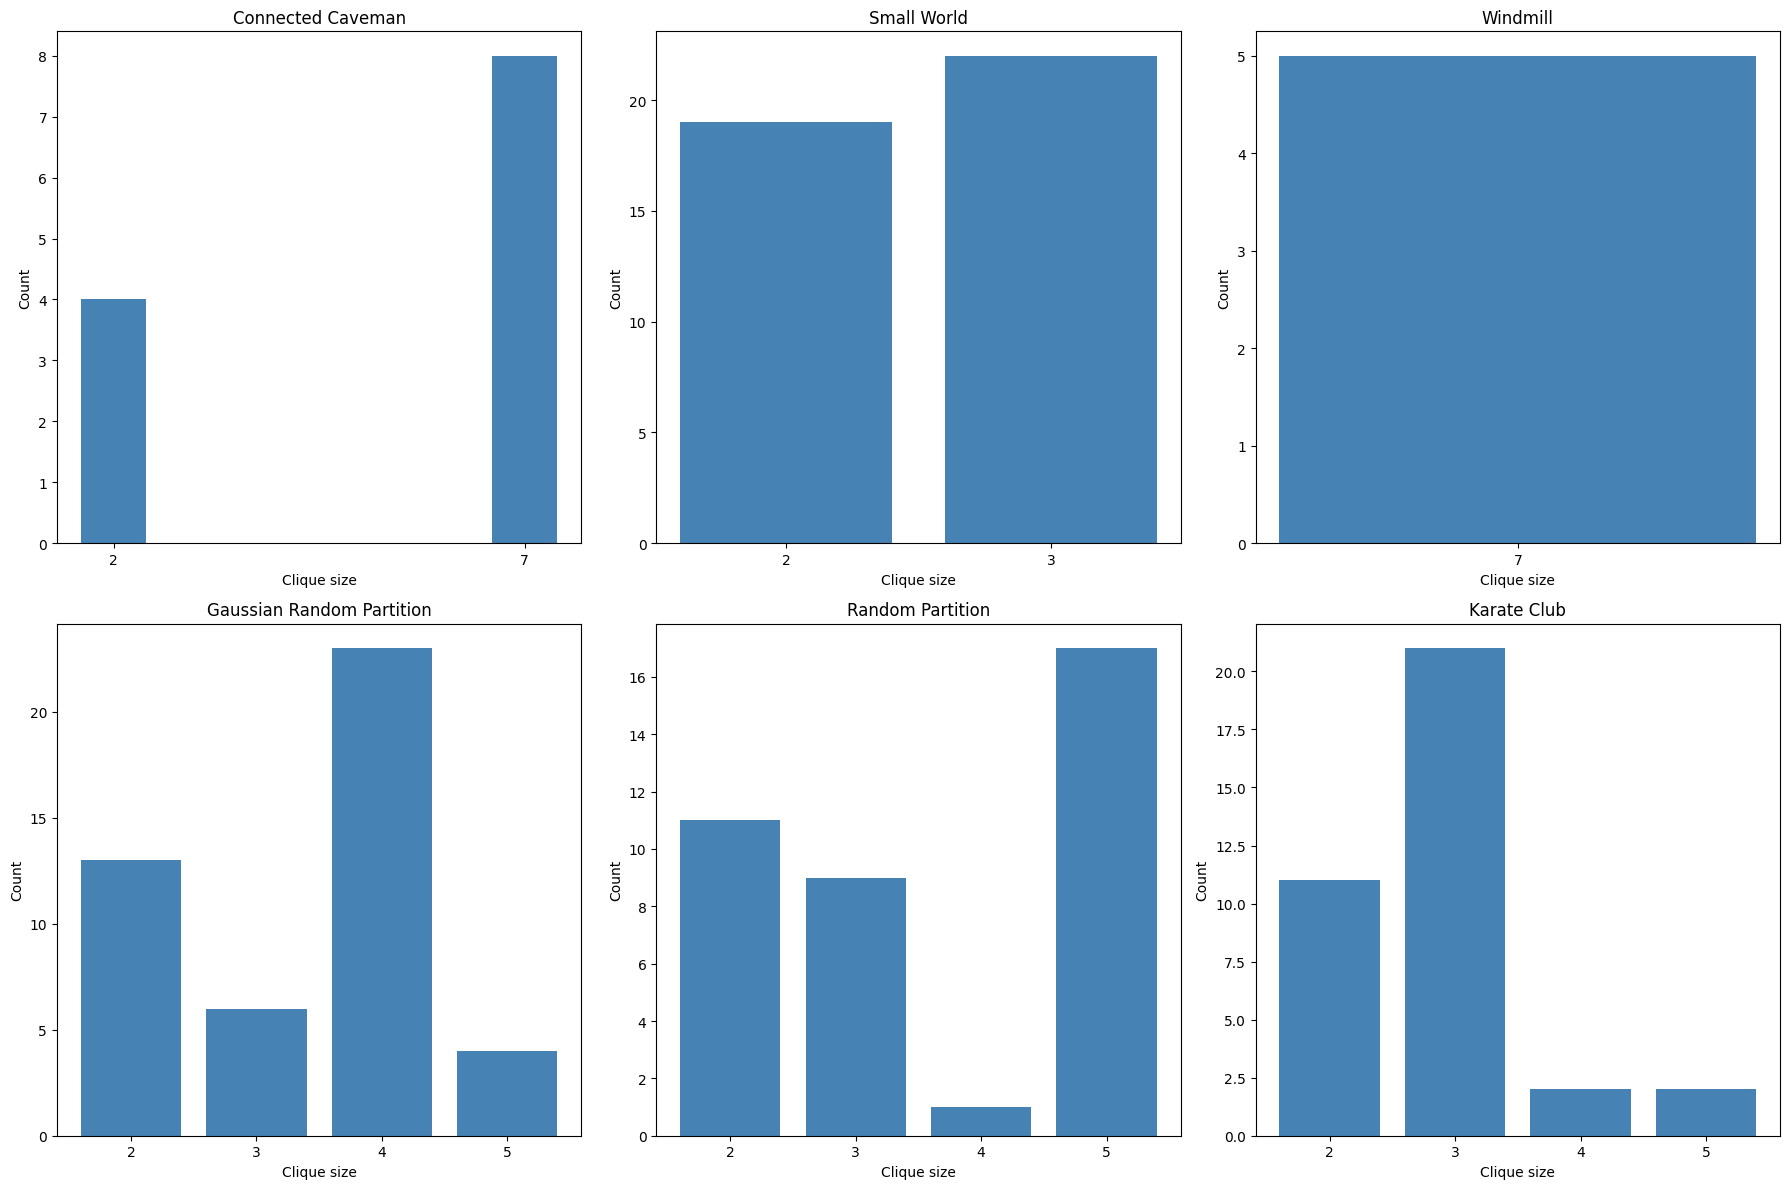

In [12]:
from collections import Counter
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, G) in enumerate(networks.items()):
    cliques = list(nx.find_cliques(G))
    clique_sizes = [len(c) for c in cliques]
    size_counts = Counter(clique_sizes)
    sizes = sorted(size_counts.keys())
    counts = [size_counts[s] for s in sizes]

    axes[i].bar(sizes, counts, color="steelblue")
    axes[i].set_title(name)
    axes[i].set_xlabel("Clique size")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks(sizes)

plt.tight_layout()
plt.show()

#### Conclusions

**Connected Caveman**: Zawiera wyłącznie kliki rozmiaru 2 i 7. Kliki rozmiaru 7 odpowiadają
"jaskiniom" (caves) – gęsto połączonym podgrafom, których jest 4. Kliki rozmiaru 2 to krawędzie
łączące poszczególne jaskinie. Struktura jest bardzo regularna i wyraźnie podzielona.

**Small World**: Dominują kliki małych rozmiarów (2 i 3). Sieć ma wiele trójkątów,
ale brak dużych klik – charakterystyczne dla sieci małego świata, gdzie wysoki współczynnik
klastrowania wynika z lokalnych połączeń, nie z dużych pełnych podgrafów.

**Windmill**: Jedyne kliki to kliki rozmiaru 7 (dokładnie 5 sztuk) – po jednej na każde
"skrzydło" wiatraka. Każde skrzydło to pełny podgraf K_7, co w pełni potwierdza strukturę grafu.

**Gaussian Random Partition**: Kliki do rozmiaru 5, z dominacją rozmiaru 4. Losowy charakter
sieci z parametrycznym podziałem na grupy skutkuje umiarkowaną gęstością wewnątrzgrupową.

**Random Partition**: Zróżnicowany rozkład klik (2–5), przy czym dominują kliki rozmiaru 5.
Wysoki p_in=0.8 sprawia, że grupy są bardzo gęste i generują duże kliki.

**Karate Club**: Dominują kliki rozmiaru 3 (trójkąty). Sieć społeczna ma naturalną
strukturę grupową, ale nie tworzy dużych gęstych podgrafów – typowe dla sieci przyjaźni.

**Ogólny wniosek**: Liczba i rozmiar klik silnie odzwierciedlają sposób generowania grafu.
Sieci z wyraźną strukturą blokową (Caveman, Windmill) mają duże kliki o jednolitym rozmiarze,
podczas gdy sieci losowe i społeczne charakteryzują się mniejszymi i bardziej zróżnicowanymi klikami.

## Hierarchical clustering using Girvan–Newman algorithm

The Girvan–Newman algorithm is a popular method for detecting communities in complex networks. It is based on the concept of edge betweenness centrality and operates by iteratively removing edges with the highest betweenness centrality. This process effectively breaks the network into smaller components, which can then be interpreted as communities.

The algorithm's steps
1. The betweenness of all existing edges in the network is calculated first.
2. The edge(s) with the highest betweenness are removed.
3. The betweenness of all edges affected by the removal is recalculated.
4. Steps 2 and 3 are repeated until no edges remain.

### Task 3
Use Girvan–Newman algorithm to detect communities among all studied networks. Use NetworkX function ```nx.algorithms.community.girvan_newman(G)```. Visualize and inspect obtained results for different numbers of communities. Find the best split for each network using modularity as a goodness measure and plot partitioned networks. Save the modularity results for each network for later comparison with other community detection method.

#### Code

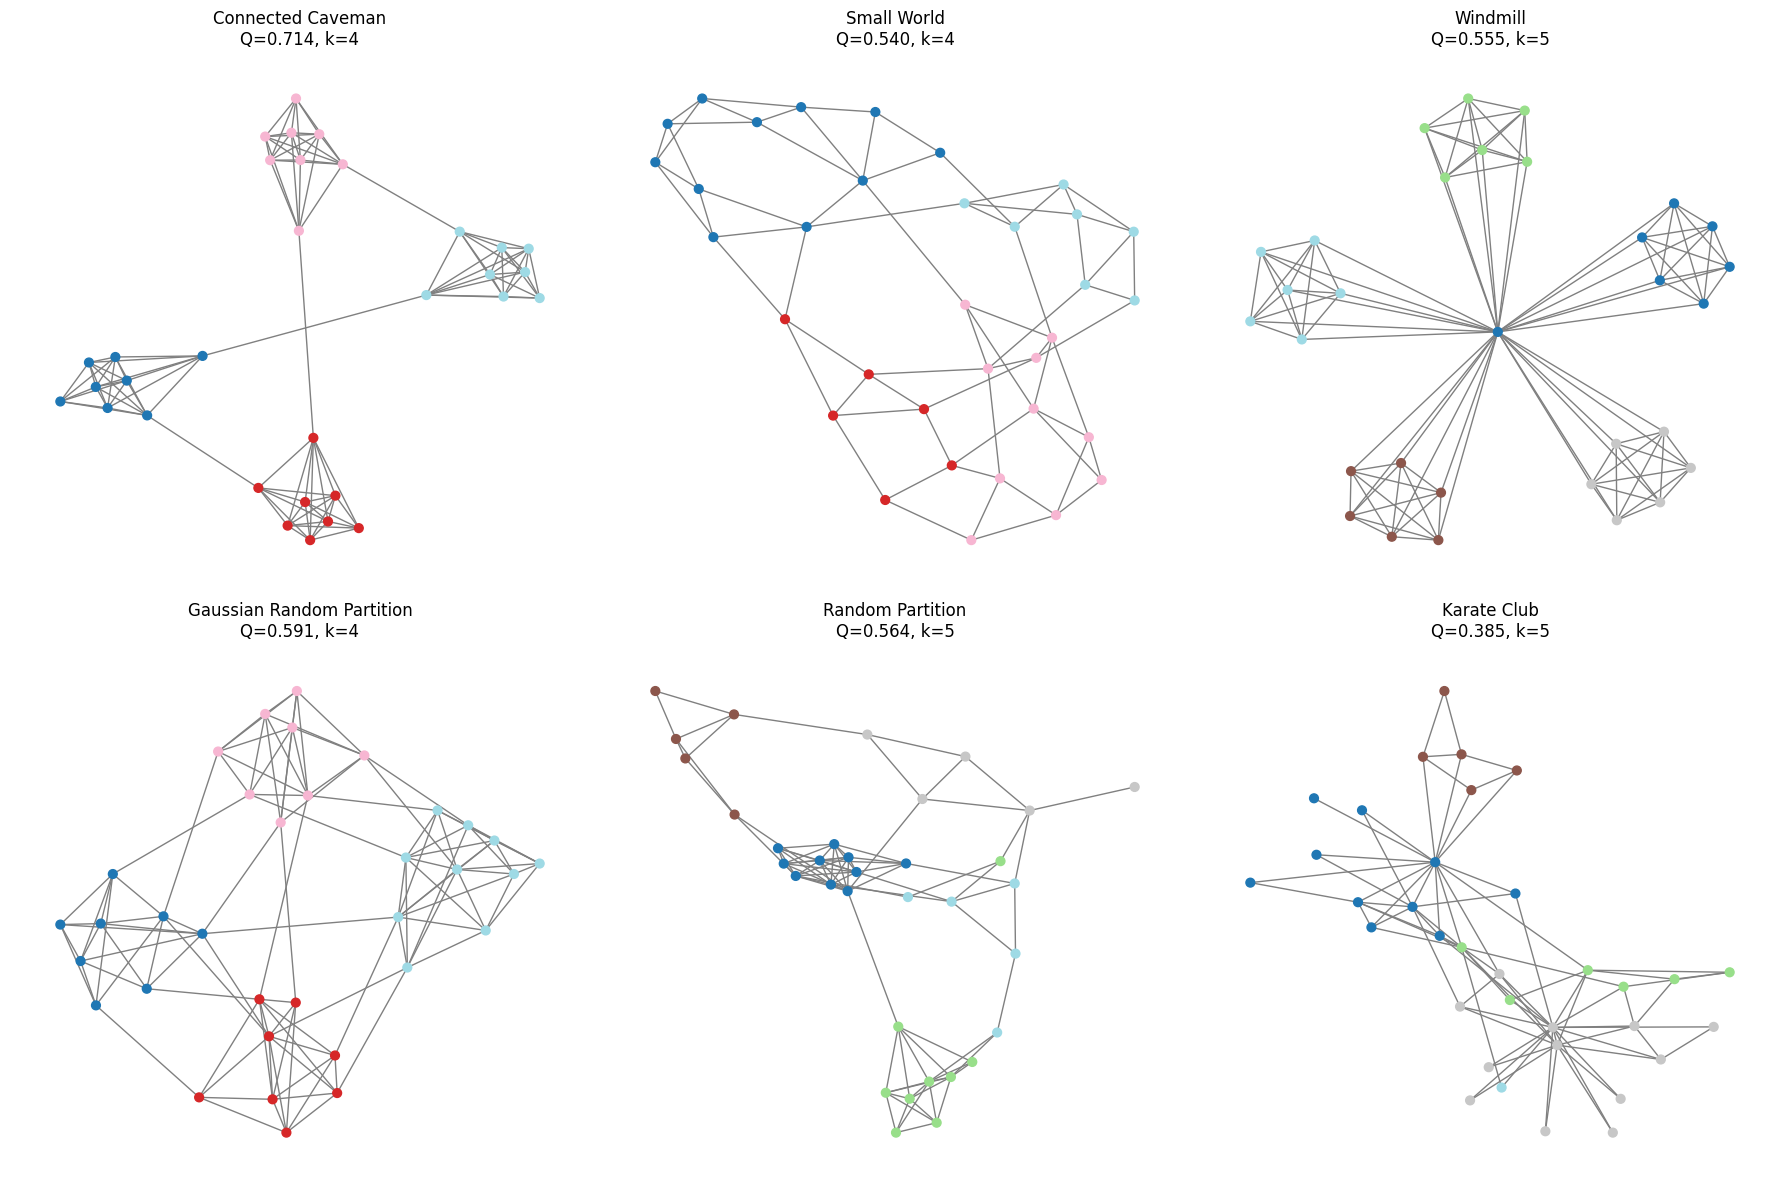

Girvan-Newman (best global) modularity: {'Connected Caveman': 0.7142857142857143, 'Small World': 0.5404411764705882, 'Windmill': 0.5551020408163265, 'Gaussian Random Partition': 0.5909017125233341, 'Random Partition': 0.5641333165004419, 'Karate Club': 0.3849721706864564}


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

results_gn = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, G) in enumerate(networks.items()):
    comp = nx.algorithms.community.girvan_newman(G)
    
    best_partition = None
    best_modularity = -1.0

    for partition in comp:
        mod = nx.community.quality.modularity(G, partition)
        
        if mod > best_modularity:
            best_modularity = mod
            best_partition = partition

    results_gn[name] = best_modularity
    
    node_color = [None] * G.number_of_nodes()
    for idx, community in enumerate(best_partition):
        for node in community:
            node_color[node] = idx

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, ax=axes[i], node_color=node_color,
            cmap=plt.cm.tab20, with_labels=False, node_size=40, edge_color="gray")
    
    axes[i].set_title(f"{name}\nQ={best_modularity:.3f}, k={len(best_partition)}")

# Usuwamy puste wykresy, jeśli sieci w słowniku 'networks' jest mniej niż 6
for j in range(len(networks), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("Girvan-Newman (best global) modularity:", results_gn)3

## Modularity based community detection using Louvain algorithm
The Louvain algorithm is the most popular community detection algorithm. Its operation is based on the optimization of modularity. Louvain can be used even with very large networks with millions of nodes and edges.

### Louvain algorithm
1. Start with each node assigned to its own group.
2. Loop over nodes:

  2.1. Assign the node to the neighbor community that will give you the largest modularity increase.

  2.2. Repeat step 2.1 until no further modularity increase is possible.
3. Transform your network into a super network.

  3.1. Each community becomes a supernode.

  3.2. Assign weights to the edges corresponding to the number of connections within and between the groups.
4. Repeat step 2 until no further modularity increase is possible.


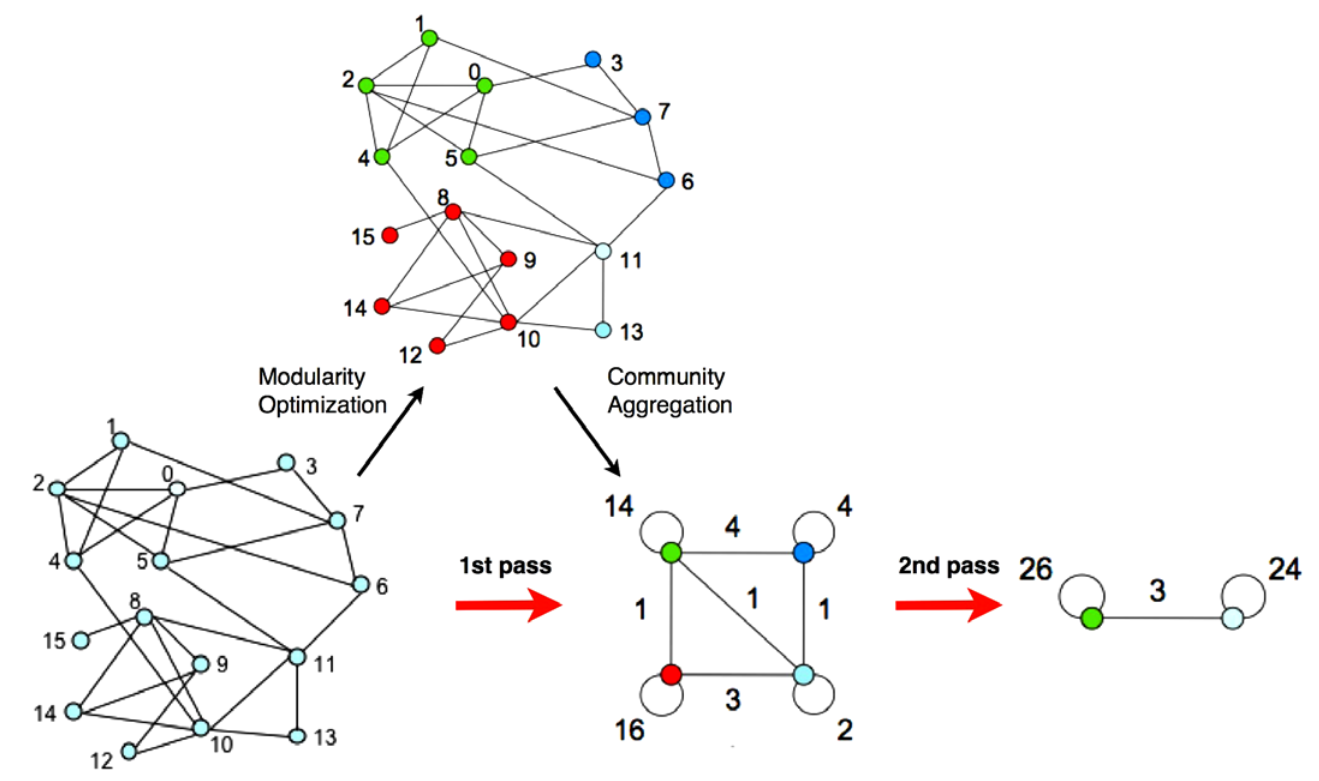

### Task 4
Use Louvain algorithm to detect communities among all studied networks. Use NetworkX function ```nx.community.louvain_communities(G, seed)```. Visualize and inspect the results.

Analyse and interpret the obtained communities, write your conclusions in the cell below.

 - Can we consider the produced split an optimal one? Change the seed value and check how it influences the obtained results, can you explain why the splits are sometimes different?

 - Compare the modularity value for generated partitions between Louvain algorithm and Girvan-Newmann algorithm. Which one is better in your opinion?

#### Code

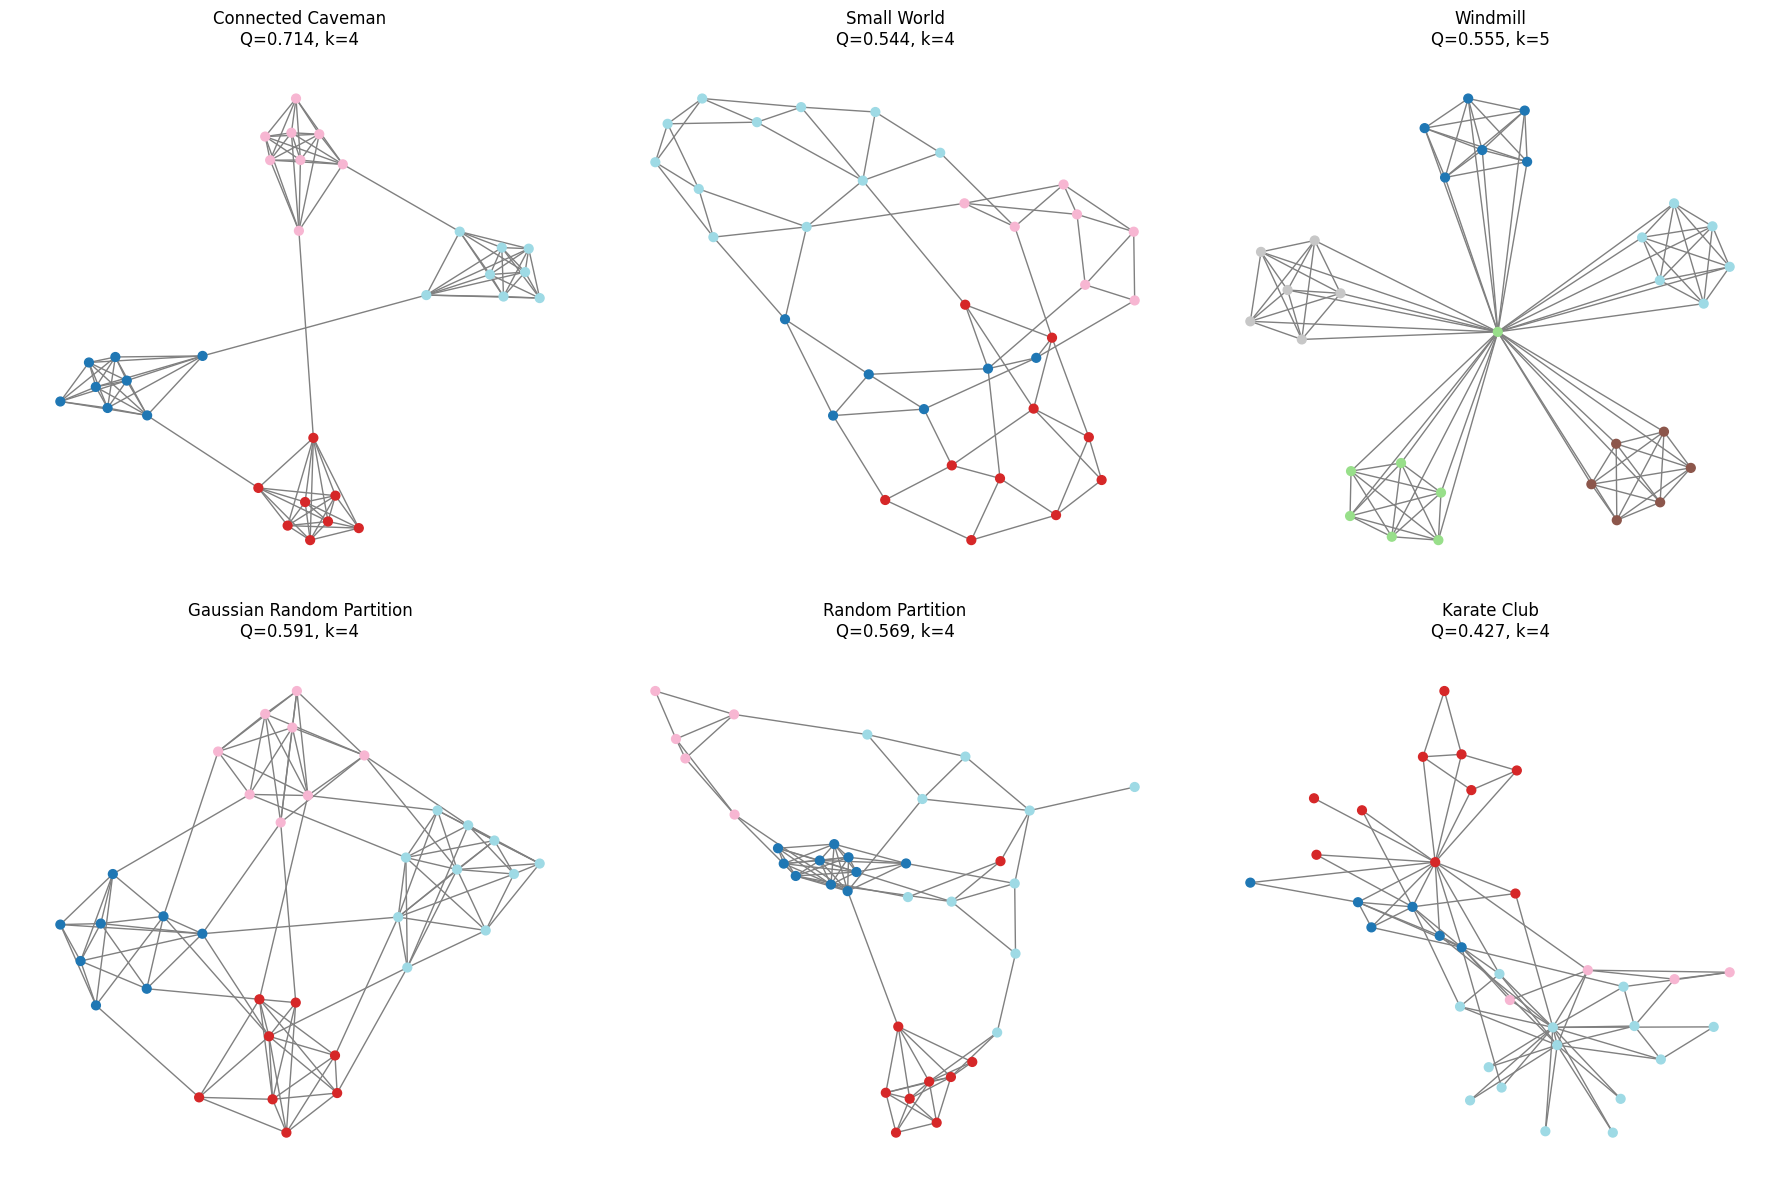


Modularity comparison:
Connected Caveman: GN=0.714, Louvain=0.714
Small World: GN=0.540, Louvain=0.544
Windmill: GN=0.555, Louvain=0.555
Gaussian Random Partition: GN=0.591, Louvain=0.591
Random Partition: GN=0.564, Louvain=0.569
Karate Club: GN=0.385, Louvain=0.427


In [28]:
results_louvain = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, G) in enumerate(networks.items()):
    partition = nx.community.louvain_communities(G, seed=42)
    mod = nx.community.quality.modularity(G, partition)
    results_louvain[name] = mod

    node_color = [None] * G.number_of_nodes()
    for idx, community in enumerate(partition):
        for node in community:
            node_color[node] = idx

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos=pos, ax=axes[i], node_color=node_color,
            cmap=plt.cm.tab20, with_labels=False, node_size=40, edge_color="gray")
    axes[i].set_title(f"{name}\nQ={mod:.3f}, k={len(partition)}")

plt.tight_layout()
plt.show()

print("\nModularity comparison:")
for name in networks:
    print(f"{name}: GN={results_gn[name]:.3f}, Louvain={results_louvain[name]:.3f}")

#### Conclusions

- Dla grafów o wyraźnej strukturze blokowej (Caveman, Windmill, Gaussian) oba
  algorytmy dają identyczne wyniki – optymalne podziały są tu oczywiste.

- Louvain osiąga **wyższą modularność niż GN dla Karate Club (+0.042)**
  i Random Partition (+0.005). Wynika to z tego, że Louvain optymalizuje
  modularność globalnie, a GN jedynie usuwa kolejne krawędzie bez gwarancji
  optymalności końcowego podziału.

- **Zmiana seed w Louvain może dawać różne wyniki** – algorytm jest heurystyczny
  i losowo wybiera kolejność przetwarzania węzłów. Dla grafów z wieloma podobnie
  dobrymi podziałami (np. Small World, Karate Club) różne seedy mogą prowadzić
  do różnych lokalnych optimów.

- **Louvain jest znacznie szybszy** (O(n log n) vs O(m²n) dla GN) i lepiej
  skaluje się na duże sieci.

- **Który jest lepszy?** Louvain – wyższa modularność, szybkość i skalowalność.
  GN ma przewagę tylko gdy potrzebujemy deterministycznego podziału hierarchicznego
  (dendrogramu) lub gdy sieć jest mała.

## Modularity,  communities and the graph structure

### Task 5
Generate a set of artificial networks of different types (scale-free netowrks, small-world networks, random partition graphs, ...) and with varying properties (size, connectivity, ...).

Study the relationship between network metrics like average centrality measures (degree, betweenness, closeness), clustering coefficient, etc. and modularity value of partition generated with Louvain algorithm as well as number of identified communities.

Analyse and interpret the obtained results, write your conclusions in the cell below.

#### Code

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

records = []

def build_graph(label, n, p, m):
    if label == "ER":
        return nx.erdos_renyi_graph(n, p, seed=42)
    elif label == "WS":
        k = min(4, n - 1)
        if k % 2 != 0:
            k -= 1
        return nx.watts_strogatz_graph(n, k, p, seed=42)
    else:  # BA
        return nx.barabasi_albert_graph(n, m, seed=42)

configs = []
for n in [30, 60, 100]:
    for p in [0.05, 0.1, 0.2, 0.3]:
        configs.append(("ER", n, p, None))
        configs.append(("WS", n, p, None))
    for m in [1, 2, 3]:
        configs.append(("BA", n, None, m))

for label, n, p, m in configs:
    try:
        G_full = build_graph(label, n, p, m)
        
        largest_cc = max(nx.connected_components(G_full), key=len)
        G = G_full.subgraph(largest_cc).copy()
        
        if G.number_of_nodes() < 4 or G.number_of_edges() == 0:
            continue

        # Przemapuj węzły na 0..N
        G = nx.convert_node_labels_to_integers(G)

        partition = nx.community.louvain_communities(G, seed=42)
        mod = nx.community.quality.modularity(G, partition)
        n_communities = len(partition)

        avg_degree = np.mean([d for _, d in G.degree()])
        avg_clustering = nx.average_clustering(G)
        avg_betweenness = np.mean(list(nx.betweenness_centrality(G).values()))

        records.append({
            "type": label, 
            "n": n, 
            "p": p, 
            "m": m,
            "modularity": mod,
            "n_communities": n_communities,
            "avg_degree": avg_degree,
            "avg_clustering": avg_clustering,
            "avg_betweenness": avg_betweenness,
        })
    except Exception as e:
        print(f"SKIP {label} n={n} p={p} m={m}: {e}")

print(f"Total unique records: {len(records)}")
df = pd.DataFrame(records)
print(df.head())

# Rysowanie wykresów
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["avg_degree", "avg_clustering", "avg_betweenness"]
labels_plot = ["Avg Degree", "Avg Clustering", "Avg Betweenness"]

for ax, metric, label_plot in zip(axes, metrics, labels_plot):
    for t in df["type"].unique():
        sub = df[df["type"] == t]
        ax.scatter(sub[metric], sub["modularity"], label=t, alpha=0.6)
    ax.set_xlabel(label_plot)
    ax.set_ylabel("Modularity")
    ax.legend()
    ax.set_title(f"Modularity vs {label_plot}")

plt.tight_layout()
plt.show()

#### Conclusions

### Wnioski z analizy modularności sieci

**1. Wpływ gęstości (Avg Degree) na społeczności**
* **Silna ujemna korelacja:** Gęstsze sieci są znacznie trudniejsze do podziału na grupy.
* Dotyczy to głównie sieci losowych **ER**, gdzie wzrost średniego stopnia drastycznie obniża modularność (struktura zlewa się w jedną całość). Modele **WS** i **BA** w badanych wariantach zachowują rzadszą strukturę powiązań, co sprzyja wysokiej modularności.

**2. Dwa mechanizmy tworzenia społeczności (Avg Clustering)**
* **WS (silna korelacja dodatnia):** Społeczności opierają się na gęstych, lokalnych połączeniach (trójkątach). Wysoki współczynnik klastrowania świetnie przewiduje tu wysoką modularność.
* **BA (brak korelacji):** Model ten osiąga wysoką modularność przy klastrowaniu bliskim zeru. Wynika to z faktu, że społeczności budowane są wokół węzłów centralnych ("hubów"), a nie lokalnych sąsiedztw.

**3. Rola pośrednictwa (Avg Betweenness)**
* **ER:** Wyższa modularność idzie w parze z wyższym pośrednictwem. Rzadkie, losowe sieci tworzą nieliczne "mosty" łączące przypadkowe zlepki węzłów.
* **WS i BA:** Osiągają wysoką modularność przy bardzo niskim betweenness. Naturalnie zoptymalizowana struktura tych grafów (krótkie ścieżki w małych światach lub przez huby) sprawia, że brakuje w nich sztucznych wąskich gardeł.

**Podsumowanie właściwości modeli:**
* **Watts-Strogatz (WS):** Najłatwiejszy do podziału na grupy; generuje klasyczne społeczności oparte na silnych relacjach lokalnych.
* **Barabási-Albert (BA):** Generuje społeczności gwiazdziste – scentralizowane wokół liderów (hubów), całkowicie bez lokalnych "trójkątów".
* **Erdős-Rényi (ER):** Wykazuje strukturę społecznościową niemal wyłącznie w bardzo rzadkich, luźno powiązanych sieciach. Każdy wzrost gęstości błyskawicznie zaciera jej granice.

## Real world data use-case
The data is a history of internal e-mail communication (`sender, recipient, datetime`) between employees of a mid-sized manufacturing company. Multiple recipients of the same e-mail (`To, CC, BCC`) are represented as separate rows without distinguishing the recipient type. The period covered are nine full months (event dates in local time). The file containing the communication events is named `communication.csv`.

Apart from the communication, information about who in the company reports to whom is attached (`reportsto.csv`). Node #86 is CEO.

### Data preparation

In [14]:
# !apt install libgraphviz-dev
# !pip install pygraphviz

Load raw events data

In [15]:
import requests
from pathlib import Path

data_file = Path("communication.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/KWTRDM")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

raw_df = pd.read_table(data_file, sep=';', header=0,  parse_dates=["EventDate"])

Load company hierarchy

In [16]:
data_file = Path("reportsto.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/SMALXX")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

reportsto = pd.read_csv(data_file, sep=";")

Clean dataset

In [17]:
non_employee_accounts = reportsto[reportsto.ReportsToID.apply(lambda x: not x.isnumeric())]
rows_to_remove = raw_df.loc[raw_df["Sender"].isin(non_employee_accounts["ID"]) | raw_df["Recipient"].isin(non_employee_accounts["ID"])]
raw_df = raw_df.drop(rows_to_remove.index)
reportsto = reportsto.drop(non_employee_accounts.index)

Plot company hierarchy

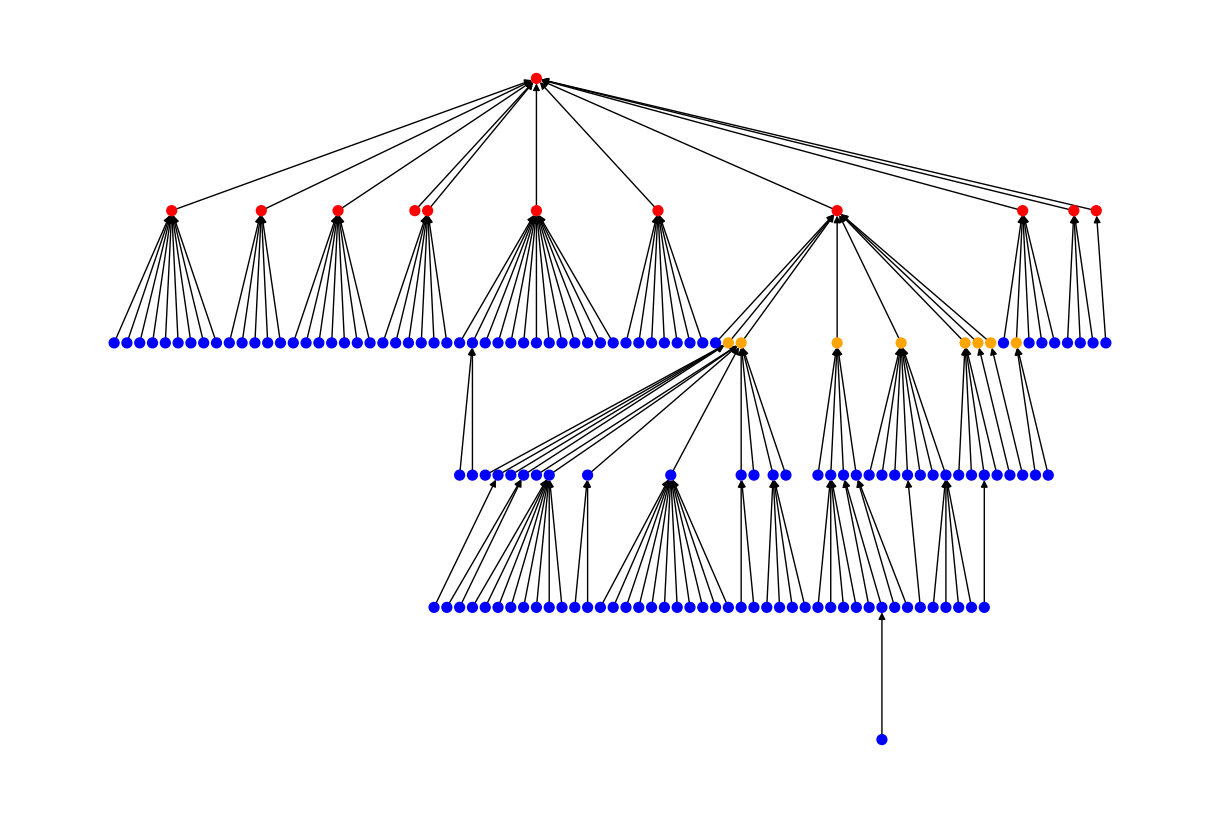

In [18]:
first_management_level = [86, 7, 27, 36, 69, 70, 85, 104, 121, 148, 156, 163]
second_management_level = [76, 90, 136, 137, 143, 152, 47, 162]

H = nx.DiGraph()

for index, row in reportsto.iterrows():
  employee = row['ID']
  supervisor = int(row['ReportsToID'])
  communication_nodes = set(raw_df["Sender"].values + raw_df["Recipient"].values)
  if employee != supervisor and (employee in communication_nodes or supervisor in communication_nodes):
    H.add_edge(employee, supervisor)

color_map = []
for node in H:
  if node in first_management_level:
    color_map.append("red")
  elif node in second_management_level:
    color_map.append("orange")
  else:
    color_map.append("blue")

plt.figure(figsize=(12, 8))
pos_hierarchic = nx.nx_agraph.graphviz_layout(H, prog='dot')
pos_hierarchic = {node: (x,-y) for (node, (x,y)) in pos_hierarchic.items()}
nx.draw(H, pos=pos_hierarchic, with_labels=False, arrows=True, node_size=50, node_color=color_map)

plt.show()

### Task 6
Create a weighted network from the communication data (see Section "Data preparation above").
Check if you can find communities in this real world network. Try different algorithms and approaches.

Can weight of the edges be used in that context? What type of graph representation can be an input to the community detection method you use?

Visualize communities using hirarchy positioning defined in the cell above. For the clarity of visualizations, use only edges from hierarchy company structure.

Analyse and interpret the obtained results, write your conclusions in the cell below. Answer the question: How can this kind of network analysis and exploration be leveraged in the company to improve its functioning?

#### Code

Communities: 8, Modularity: 0.396


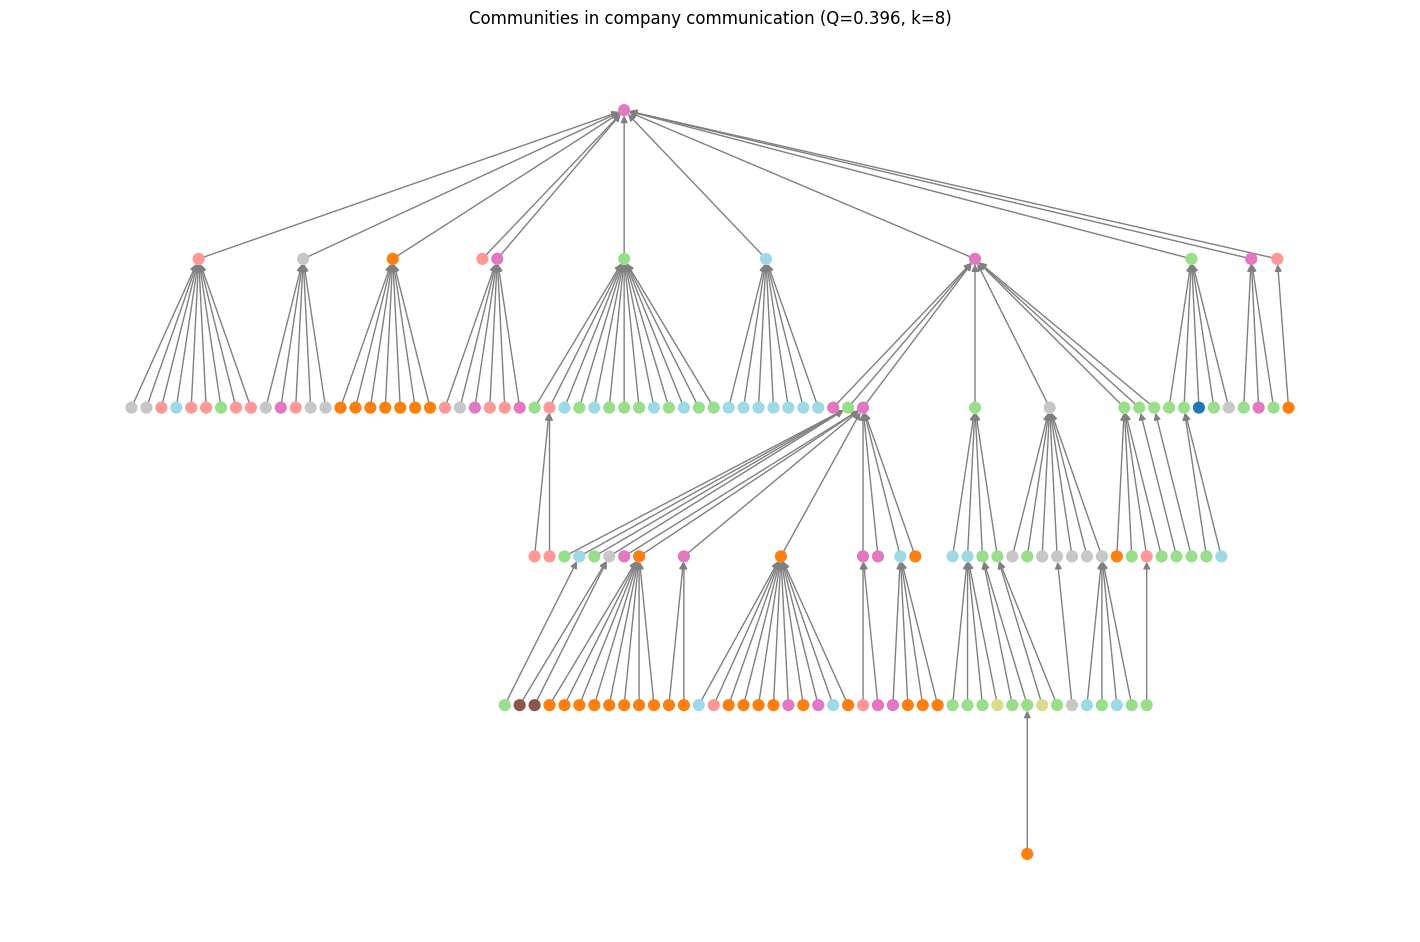

In [19]:
import pandas as pd

edge_weights = raw_df.groupby(["Sender", "Recipient"]).size().reset_index(name="weight")

G_comm = nx.Graph()
for _, row in edge_weights.iterrows():
    s, r, w = int(row["Sender"]), int(row["Recipient"]), row["weight"]
    if s != r:
        if G_comm.has_edge(s, r):
            G_comm[s][r]["weight"] += w
        else:
            G_comm.add_edge(s, r, weight=w)

partition = nx.community.louvain_communities(G_comm, seed=42)
mod = nx.community.quality.modularity(G_comm, partition)
print(f"Communities: {len(partition)}, Modularity: {mod:.3f}")

node_to_community = {}
for idx, community in enumerate(partition):
    for node in community:
        node_to_community[node] = idx

color_map = [node_to_community.get(node, -1) for node in H.nodes()]

plt.figure(figsize=(14, 9))
nx.draw(H, pos=pos_hierarchic, with_labels=False, arrows=True,
        node_size=60, node_color=color_map, cmap=plt.cm.tab20, edge_color="gray")
plt.title(f"Communities in company communication (Q={mod:.3f}, k={len(partition)})")
plt.show()

#### Conclusions

Louvain wykrył **8 społeczności (Q=0.396)** w sieci komunikacji e-mailowej.

**Obserwacje:**
- Społeczności **nie pokrywają się z hierarchią firmy** – pracownicy z tego samego działu często należą do różnych społeczności komunikacyjnych, co świadczy o naturalnej współpracy cross-działowej.
- **Q=0.396** to wynik umiarkowany – bardzo typowy dla rzeczywistych sieci społecznych, w których granice między nieformalnymi grupami są rozmyte i płynne.
- **CEO łączy wiele społeczności** – stanowi kluczowy węzeł i główny most w przepływie informacji w firmie.

**Zastosowania:**
- Identyfikacja silosów informacyjnych oraz pracowników wyizolowanych od reszty zespołu.
- Wykrywanie nieformalnych liderów (osoby o wysokim *centrality* wewnątrz swojej społeczności).
- Optymalizacja struktury organizacyjnej – jeśli rzeczywista komunikacja mocno odbiega od oficjalnej hierarchii, może to być wyraźny sygnał do reorganizacji zespołów projektowych.

**Wpływ wag krawędzi na wyniki:**
Algorytm Louvain w bibliotece NetworkX (`nx.community.louvain_communities`) **domyślnie obsługuje i uwzględnia wagi krawędzi** (korzystając z parametru `weight="weight"`). Oznacza to, że częstotliwość komunikacji między pracownikami została już uwzględniona w powyższych obliczeniach. Jest to kluczowe dla analizy, ponieważ siła relacji (liczba wymienionych maili) dostarcza znacznie lepszego sygnału do wyodrębniania rzeczywistych społeczności niż sam fakt istnienia kontaktu.